# Setup

In [43]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely import wkt, Polygon, MultiPolygon, box

In [4]:
df = pd.read_csv('swiss-dwellings-v3.0.0/geometries.csv')
df['geometry'] = df['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Load SD geometry.csv dataset as dataframe and explore data

### DF analysis

In [7]:
print(df.shape)
print(df.head())

(3255905, 13)
                       apartment_id  site_id  building_id  plan_id  floor_id  \
0  3c3b1d6ca8b4b9092480b8c75f9eaa81      210          399     1054      1588   
1  3c3b1d6ca8b4b9092480b8c75f9eaa81      210          399     1054      1588   
2  3c3b1d6ca8b4b9092480b8c75f9eaa81      210          399     1054      1588   
3  3c3b1d6ca8b4b9092480b8c75f9eaa81      210          399     1054      1588   
4  3c3b1d6ca8b4b9092480b8c75f9eaa81      210          399     1054      1588   

   unit_id   area_id   unit_usage entity_type entity_subtype  \
0   7300.0  619311.0  RESIDENTIAL        area       BATHROOM   
1   7300.0  619303.0  RESIDENTIAL        area    LIVING_ROOM   
2   7300.0  619322.0  RESIDENTIAL        area           ROOM   
3   7300.0  619310.0  RESIDENTIAL        area        KITCHEN   
4   7300.0  619312.0  RESIDENTIAL        area           ROOM   

                                            geometry  elevation  height  
0  POLYGON ((-2.7337844078265210 4.07980744083

In [ ]:
missing_values = df.isna().sum()
print(missing_values)

# show some rows with missing values
print(df[df['apartment_id'].isna()].head())

apartment_id       588501
site_id                 0
building_id             0
plan_id                 0
floor_id                0
unit_id            588501
area_id           2415749
unit_usage              0
entity_type             0
entity_subtype          0
geometry                0
elevation               0
height                  0
dtype: int64
    apartment_id  site_id  building_id  plan_id  floor_id  unit_id   area_id  \
330          NaN      210          399     1054      1588      NaN  619318.0   
331          NaN      210          399     1054      1588      NaN  662782.0   
332          NaN      210          399     1054      1588      NaN  619304.0   
333          NaN      210          399     1054      1588      NaN  662782.0   
334          NaN      210          399     1054      1588      NaN       NaN   

    unit_usage entity_type entity_subtype  \
330     PUBLIC        area          SHAFT   
331     PUBLIC        area      STAIRCASE   
332     PUBLIC        area       

apartment_id, unit_id and area_id 
are missing in some rows this may be because there are some common elements such as SHAFT, STAIRCASE, STAIRS, WALL, etc. for which it does not make sense to have these fields

### Distributions

In [14]:
print(gdf.describe())

            site_id   building_id       plan_id      floor_id       unit_id  \
count  3.255905e+06  3.255905e+06  3.255905e+06  3.255905e+06  2.667404e+06   
mean   2.588307e+03  4.398214e+03  1.316622e+04  1.744027e+04  6.719335e+04   
std    3.734114e+03  5.722709e+03  1.467519e+04  1.660160e+04  4.844788e+04   
min    1.700000e+01  1.000000e+00  2.000000e+00  2.000000e+00  4.967000e+03   
25%    4.690000e+02  1.121000e+03  3.383000e+03  5.200000e+03  2.813600e+04   
50%    9.190000e+02  2.047000e+03  6.254000e+03  1.033900e+04  5.324800e+04   
75%    2.272000e+03  3.392000e+03  1.651100e+04  2.539500e+04  1.001400e+05   
max    1.192300e+04  1.865500e+04  4.439600e+04  5.172500e+04  1.616240e+05   

            area_id     elevation        height  
count  8.401560e+05  3.255905e+06  3.255905e+06  
mean   7.819682e+05  7.336867e+00  2.216333e+00  
std    4.569955e+05  6.786311e+00  6.454510e-01  
min    2.736420e+05 -1.160000e+01  2.000000e-01  
25%    4.097040e+05  2.900000e+00  2.0

Looking at the elevation field we observe that basement floors are present, and comparing mean and median shows that most floors reside at high levels.
The geometric height of the floors on average is 2.2 m, typical of habitable rooms

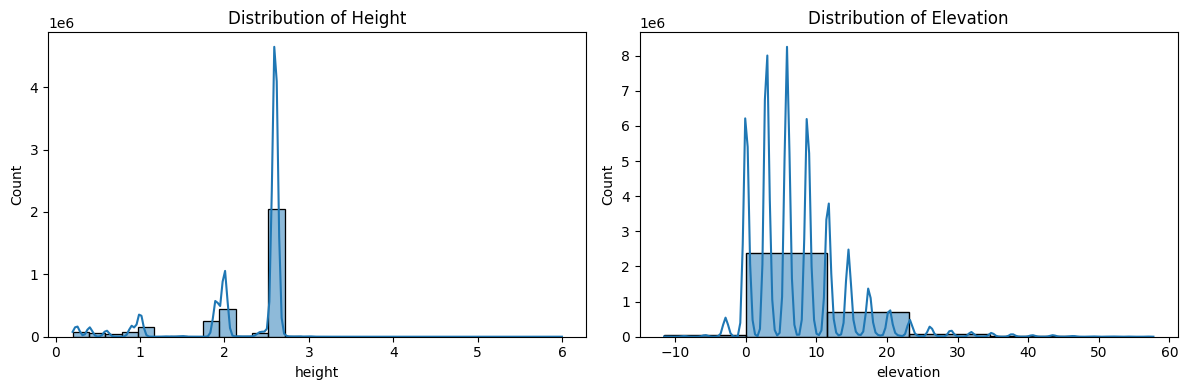

In [13]:
plt.figure(figsize=(12, 4))

# Istogramma
plt.subplot(1, 2, 1)
sns.histplot(gdf['height'], bins=30, kde=True)
plt.title("Distribution of Height")

# Boxplot
plt.subplot(1, 2, 2)
sns.histplot(gdf['elevation'], bins=6, kde=True)
plt.title("Distribution of Elevation")

plt.tight_layout()
plt.show()

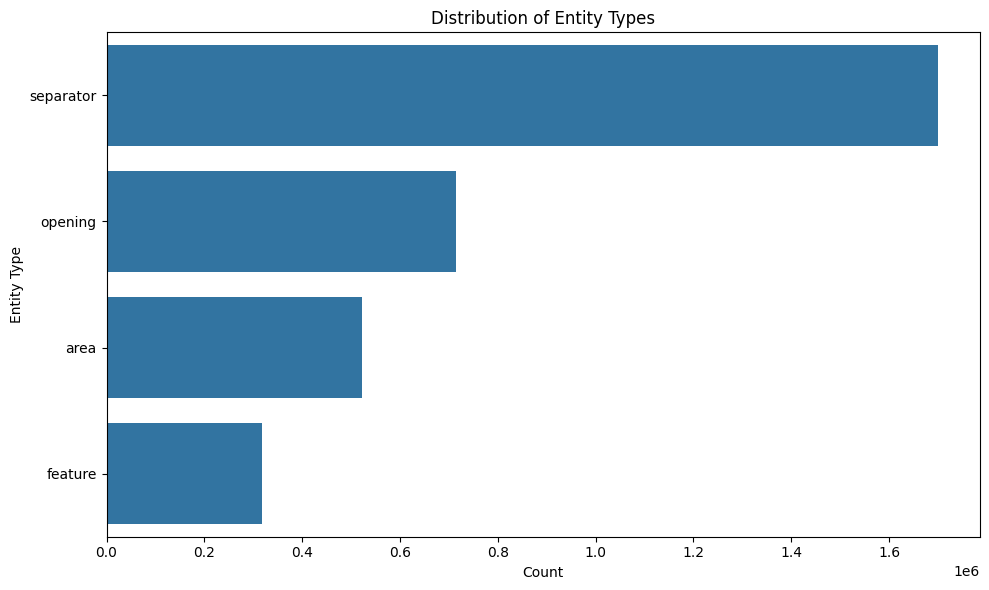

In [12]:
entity_counts = gdf['entity_type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=entity_counts.values, y=entity_counts.index)
plt.title("Distribution of Entity Types")
plt.xlabel("Count")
plt.ylabel("Entity Type")
plt.tight_layout()
plt.show()

In total, the datasets contain the 2D geometry of ~1.7 million separators (walls, railings), ~715,000 openings (windows, doors), ca. 520,000 areas (rooms, bathrooms, kitchens, etc.), and ~315,000 features (sinks, toilets, bathtubs, etc.).
Openings and Separator are not presents in case of area_id is missing

In [4]:
entity_types = set(df['entity_type'].unique)
for entity_type in entity_types:
    print(f'Type: {entity_type}\n'
          f'-- Subtypes:\n\t{[cat.lower() for cat in set(df[df["entity_type"]==entity_type].entity_subtype)]}\n')

Type: feature
-- Subtypes:
	['built_in_furniture', 'elevator', 'washing_machine', 'ramp', 'bathtub', 'stairs', 'sink', 'shower', 'kitchen', 'toilet']

Type: separator
-- Subtypes:
	['wall', 'railing', 'column']

Type: area
-- Subtypes:
	['shelter', 'lightwell', 'vehicle_traffic_area', 'heating', 'open_plan_office', 'medical_room', 'radation_therapy', 'loggia', 'patio', 'dining', 'warehouse', 'foyer', 'reception_room', 'water_supply', 'showroom', 'room', 'corridor', 'house_technics_facilities', 'outdoor_void', 'corridors_and_halls', 'void', 'common_kitchen', 'teaching_room', 'oil_tank', 'wintergarten', 'air', 'canteen', 'arcade', 'transport_shaft', 'pram_and_bike_storage_room', 'dedicated_medical_room', 'carpark', 'workshop', 'break_room', 'living_room', 'office_space', 'gas', 'lobby', 'living_dining', 'balcony', 'wash_and_dry_room', 'shaft', 'kitchen', 'pram', 'technical_area', 'staircase', 'kitchen_dining', 'elevator_facilities', 'elevator', 'physio_and_rehabilitation', 'office_tech_r

In [21]:
area_subtypes = gdf[gdf['entity_type'] == 'area']['entity_subtype'].value_counts()

# count subtypes for area entity type
for i, v in area_subtypes.items():
    print(f"{i}: {v}")

SHAFT: 100389
ROOM: 83715
BATHROOM: 70317
CORRIDOR: 63514
KITCHEN: 44477
BALCONY: 43720
LIVING_DINING: 24435
BEDROOM: 23180
STOREROOM: 19072
STAIRCASE: 12903
ELEVATOR: 11313
LIVING_ROOM: 8486
LOGGIA: 4670
VOID: 3221
DINING: 1322
NOT_DEFINED: 1125
BASEMENT_COMPARTMENT: 1004
TERRACE: 640
CORRIDORS_AND_HALLS: 541
LIGHTWELL: 539
OFFICE: 376
WINTERGARTEN: 354
BASEMENT: 348
WASH_AND_DRY_ROOM: 334
OFFICE_SPACE: 258
TECHNICAL_AREA: 190
GARDEN: 188
PATIO: 183
LOBBY: 135
OUTDOOR_VOID: 118
SANITARY_ROOMS: 95
COMMUNITY_ROOM: 94
OFFICE_TECH_ROOM: 80
BIKE_STORAGE: 80
PRAM_AND_BIKE_STORAGE_ROOM: 74
GARAGE: 63
HEATING: 51
MEETING_ROOM: 49
KITCHEN_DINING: 44
SALESROOM: 41
SHELTER: 39
COMMON_KITCHEN: 35
CARPARK: 34
SPORTS_ROOMS: 32
OPERATIONS_FACILITIES: 29
WAREHOUSE: 27
OPEN_PLAN_OFFICE: 22
PRAM: 17
ARCHIVE: 16
WAITING_ROOM: 15
HOUSE_TECHNICS_FACILITIES: 15
OIL_TANK: 15
TRANSPORT_SHAFT: 14
VEHICLE_TRAFFIC_AREA: 14
ELEVATOR_FACILITIES: 13
MEDICAL_ROOM: 12
ELECTRICAL_SUPPLY: 12
CLOAKROOM: 10
FOYER: 10
SH

In [23]:
separator_subtypes = gdf[gdf['entity_type'] == 'separator']['entity_subtype'].value_counts()

# count subtypes for area entity type
for i, v in separator_subtypes.items():
    print(f"{i}: {v}")

WALL: 1519546
RAILING: 158398
COLUMN: 22869


### Geometries

In [9]:
# 1. Filtra solo poligoni (Polygon e MultiPolygon)
polygon_gdf = gdf[gdf['geometry'].geom_type.isin(['Polygon', 'MultiPolygon'])]

# 3. Numero di vertici (complessità)
def count_vertices(geom):
    if isinstance(geom, Polygon):
        return len(geom.exterior.coords)
    elif isinstance(geom, MultiPolygon):
        return sum(len(p.exterior.coords) for p in geom.geoms)
    return 0

# 4. Poligoni con buchi
def count_interior_rings(geom):
    if isinstance(geom, Polygon):
        return len(geom.interiors)
    elif isinstance(geom, MultiPolygon):
        return sum(len(p.interiors) for p in geom.geoms)
    return 0

In [12]:
polygon_gdf['area'] = polygon_gdf['geometry'].area
polygon_gdf['n_vertices'] = polygon_gdf['geometry'].apply(count_vertices)
polygon_gdf['holes'] = polygon_gdf['geometry'].apply(count_interior_rings)

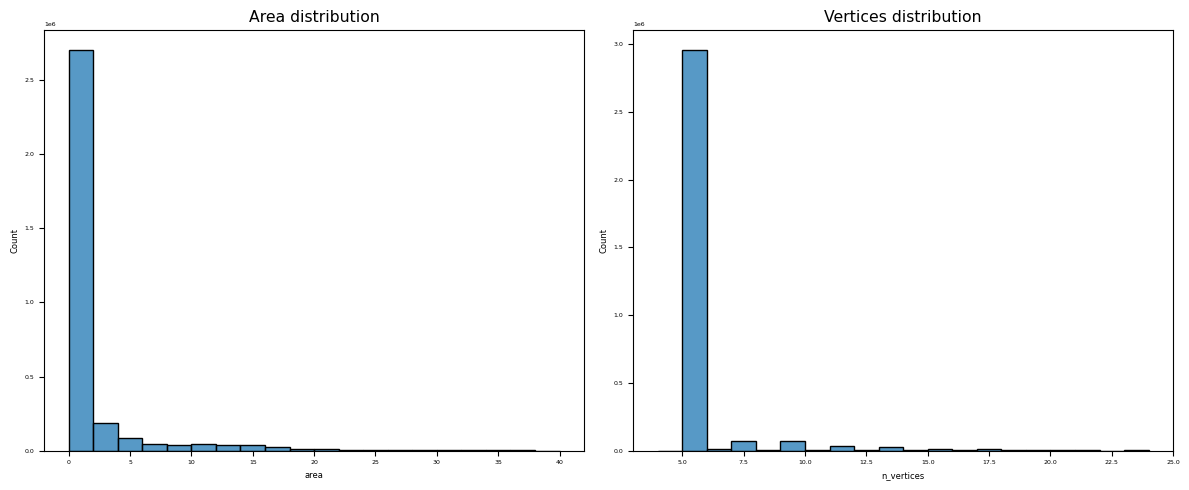

In [105]:
# filtering for understanding the more dense distribution 
area_df = polygon_gdf[(polygon_gdf['area'] < 40)]
vertex_df = polygon_gdf[(polygon_gdf['n_vertices'] < 25)]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(area_df['area'], bins=20)
plt.title("Area distribution")

plt.subplot(1, 2, 2)
sns.histplot(vertex_df['n_vertices'], bins=20)
plt.title("Vertices distribution")

plt.tight_layout()
plt.show()

Polygon with at least 1 hole: 1


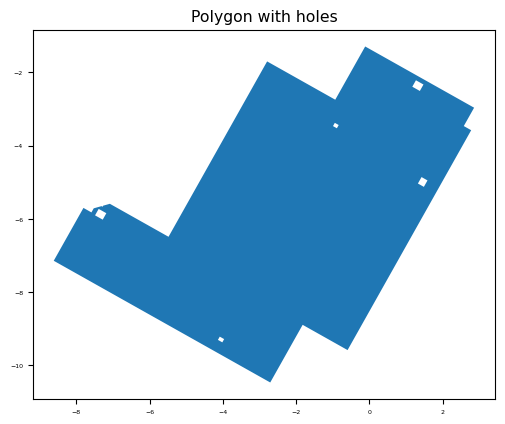

In [ ]:
polygons_with_holes = polygon_gdf[polygon_gdf['holes'] > 0].iloc[[0]]

print(f"Polygon with at least 1 hole: {len(polygons_with_holes)}")

polygons_with_holes.plot()


plt.title("Polygon with holes")
plt.show()

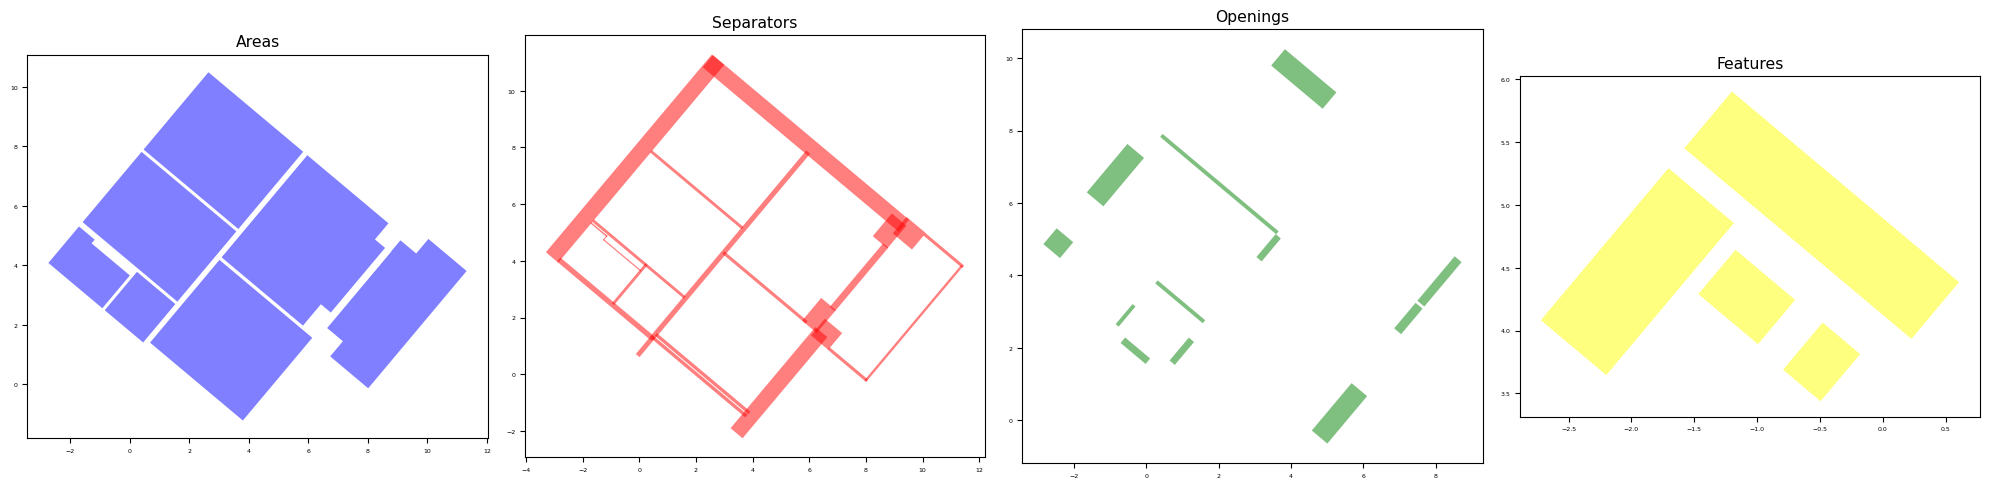

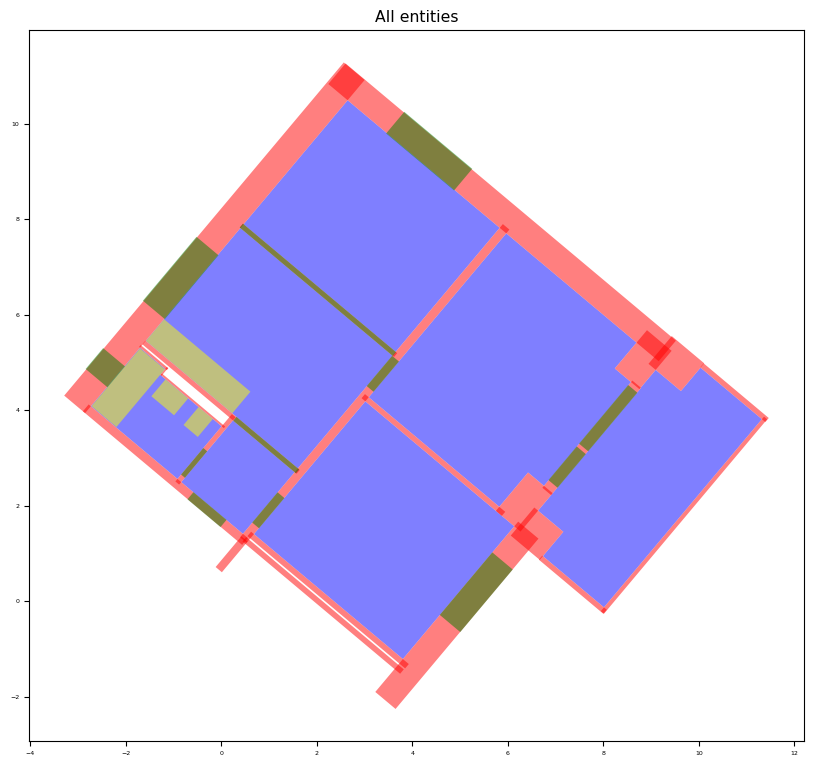

In [ ]:
#select an apartment_id
apartment_id = "3c3b1d6ca8b4b9092480b8c75f9eaa81"

#select all entities for the apartment_id
building = gdf[gdf['apartment_id'] == apartment_id]

#subplot all areas , separator , openings , features
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

building[building['entity_type'] == 'area'].plot(ax=ax[0], color='blue', alpha=0.5)
building[building['entity_type'] == 'separator'].plot(ax=ax[1], color='red', alpha=0.5)
building[building['entity_type'] == 'opening'].plot(ax=ax[2], color='green', alpha=0.5)
building[building['entity_type'] == 'feature'].plot(ax=ax[3], color='yellow', alpha=0.5)

#insert title
ax[0].set_title("Areas")
ax[1].set_title("Separators")
ax[2].set_title("Openings")
ax[3].set_title("Features")

plt.tight_layout()
plt.show()

# plot all together with different colors
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

sep_colors = ['blue', 'red', 'green', 'yellow']
sep_names = ['Area', 'Separator', 'Opening', 'Feature']

building[building['entity_type'] == 'area'].plot(ax=ax, color='blue', alpha=0.5)
building[building['entity_type'] == 'separator'].plot(ax=ax, color='red', alpha=0.5)
building[building['entity_type'] == 'opening'].plot(ax=ax, color='green', alpha=0.5)
building[building['entity_type'] == 'feature'].plot(ax=ax, color='yellow', alpha=0.5)

plt.title("All entities")
plt.show()


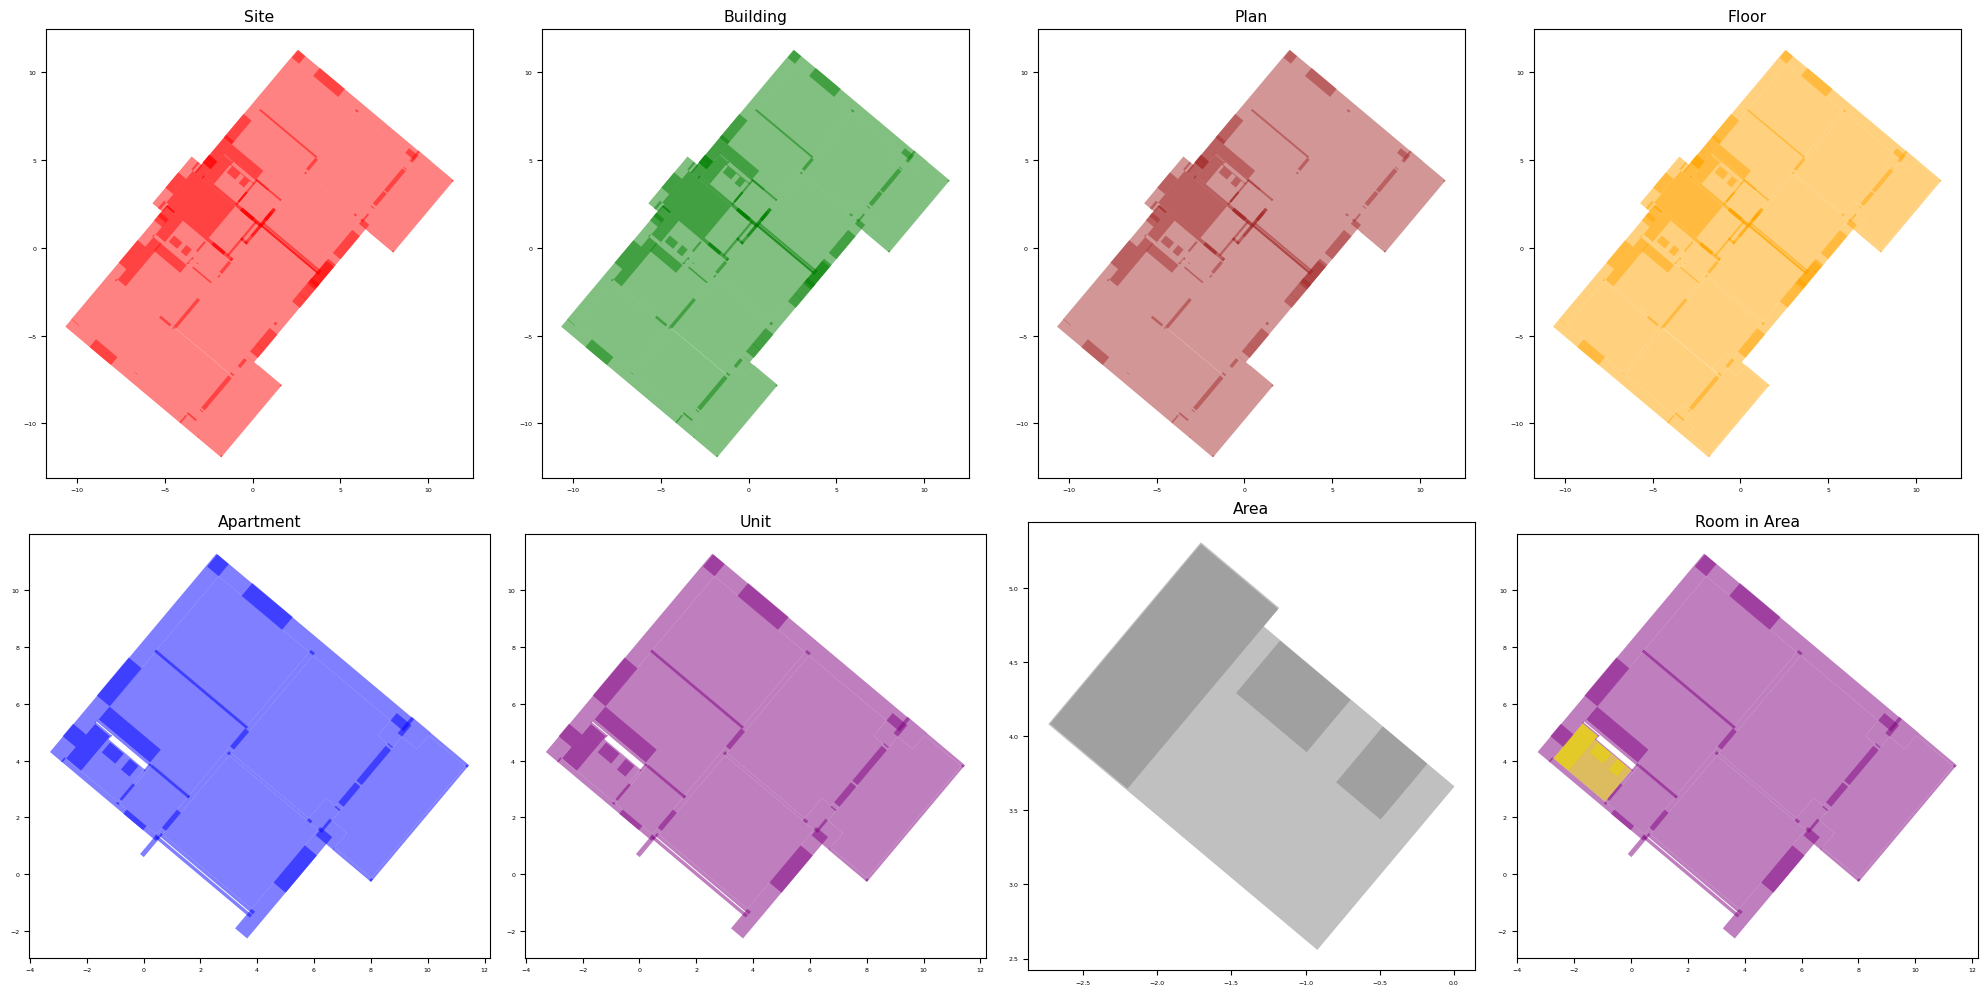

In [99]:
record = 0

apartment_id = gdf['apartment_id'].values[record]
site_id = gdf['site_id'].values[record]
building_id = gdf['building_id'].values[record]
plan_id = gdf['plan_id'].values[record]
floor_id = gdf['floor_id'].values[record]
unit_id = gdf['unit_id'].values[record]
area_id = gdf['area_id'].values[record]

apartment = gdf[(gdf['apartment_id'] == apartment_id)]
site = gdf[(gdf['site_id'] == site_id)]
building = gdf[(gdf['building_id'] == building_id)]
plan = gdf[(gdf['plan_id'] == plan_id)]
floor = gdf[(gdf['floor_id'] == floor_id)]
unit = gdf[(gdf['unit_id'] == unit_id)]
area = gdf[(gdf['area_id'] == area_id)]

fig, ax = plt.subplots(2, 4, figsize=(20, 10))  
ax = ax.flatten()  

site.plot(ax=ax[0], color='red', alpha=0.2)
building.plot(ax=ax[1], color='green', alpha=0.2)
plan.plot(ax=ax[2], color='brown', alpha=0.2)
floor.plot(ax=ax[3], color='orange', alpha=0.5)
apartment.plot(ax=ax[4], color='blue', alpha=0.5)
unit.plot(ax=ax[5], color='purple', alpha=0.5)
area.plot(ax=ax[6], color='grey', alpha=0.2)
unit.plot(ax=ax[7], color='purple', alpha=0.5)
area.plot(ax=ax[7], color='yellow', alpha=0.2)

ax[0].set_title("Site")
ax[1].set_title("Building")
ax[2].set_title("Plan")
ax[3].set_title("Floor")
ax[4].set_title("Apartment")
ax[5].set_title("Unit")
ax[6].set_title("Area")
ax[7].set_title("Room in Area")

plt.tight_layout()
plt.show()

Note that multiple floors (floor_id) of a building might be based on the same plan (same plan_id)

## Floor level experiments

In [39]:
floor_id = gdf['floor_id'].values[0]
floor = gdf[gdf['floor_id'] == floor_id].copy()
print(floor.shape)
floor.head()

(140, 13)


,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geometry,elevation,height
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,"POLYGON ((-2.73378 4.07981, -1.70530 5.30551, ...",0.0,2.6
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,"POLYGON ((5.82790 7.81688, 3.64914 5.22033, 0....",0.0,2.6
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,"POLYGON ((6.75571 2.41337, 6.42279 2.69272, 5....",0.0,2.6
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,"POLYGON ((3.58212 5.14046, 1.60055 2.77892, -1...",0.0,2.6
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,"POLYGON ((3.01414 4.18206, 6.13291 1.56509, 3....",0.0,2.6


### Geometric properties

In [ ]:
floor['area'] = floor.geometry.area
floor['perimeter'] = floor.geometry.length
floor['centroid'] = floor.geometry.centroid
floor['n_vertices'] = floor.geometry.apply(lambda p: len(p.exterior.coords) if p.geom_type == 'Polygon' else 0)
floor['n_holes'] = floor.geometry.apply(lambda p: len(p.interiors) if p.geom_type == 'Polygon' else 0)

# Extract the bounding box coordinates (minx, miny, maxx, maxy) for each geometry
bounds_df = pd.DataFrame(floor.geometry.bounds, columns=['minx', 'miny', 'maxx', 'maxy'])
floor = pd.concat([floor.reset_index(drop=True), bounds_df.reset_index(drop=True)], axis=1)

floor[['floor_id', 'geometry', 'area', 'perimeter', 'centroid', 'n_vertices', 'n_holes', 'minx', 'miny', 'maxx', 'maxy']].head()

,floor_id,geometry,area,perimeter,centroid,n_vertices,n_holes,minx,miny,maxx,maxy
0,1588,"POLYGON ((-2.73378 4.07981, -1.70530 5.30551, ...",3.515454,7.934030,POINT (-1.36905 3.90644),7,0,-2.733784,2.558345,0.003837,5.305510
1,1588,"POLYGON ((5.82790 7.81688, 3.64914 5.22033, 0....",14.088640,15.092084,POINT (3.14649 7.85447),5,0,0.465081,5.220328,5.827899,10.488616
2,1588,"POLYGON ((6.75571 2.41337, 6.42279 2.69272, 5....",17.214329,16.966812,POINT (6.00755 4.75171),9,0,3.086631,1.974660,8.693621,7.700563
3,1588,"POLYGON ((3.58212 5.14046, 1.60055 2.77892, -1...",12.813539,14.478536,POINT (0.99931 5.29556),5,0,-1.583507,2.778915,3.582120,7.812201
4,1588,"POLYGON ((3.01414 4.18206, 6.13291 1.56509, 3....",14.771212,15.398857,POINT (3.40746 1.48391),5,0,0.682005,-1.214235,6.132914,4.182057


### Geometric operations

In [ ]:
ref_geom = floor.geometry.iloc[0]
#returns boolean
floor['contains_ref'] = floor.geometry.apply(lambda g: ref_geom.contains(g))
floor['intersects_ref'] = floor.geometry.apply(lambda g: ref_geom.intersects(g))

#min euclidian distance between each point of the two geometries, if they intersect the distance is 0
floor['distance_to_ref'] = floor.geometry.apply(lambda g: ref_geom.distance(g))

#returns geometry
floor['union_with_ref'] = floor.geometry.apply(lambda g: ref_geom.union(g))
floor['difference_from_ref'] = floor.geometry.apply(lambda g: ref_geom.difference(g))
floor['intersection_with_ref'] = floor.geometry.apply(lambda g: ref_geom.intersection(g))

floor[['floor_id', 'geometry', 'contains_ref', 'intersects_ref', 'distance_to_ref', 'buffered', 'union_with_ref', 'difference_from_ref', 'intersection_with_ref']].head()

,floor_id,contains_ref,intersects_ref,distance_to_ref,buffered,union_with_ref,difference_from_ref,intersection_with_ref
0,1588,True,True,0.000000,"POLYGON ((-3.05518 3.69679, -3.09117 3.73013, ...","POLYGON ((-1.70530 5.30551, -1.17808 4.86312, ...",POLYGON EMPTY,"POLYGON ((-1.70530 5.30551, -1.17808 4.86312, ..."
1,1588,False,False,3.376511,"POLYGON ((6.14929 8.19990, 6.18529 8.16655, 6....","MULTIPOLYGON (((-2.73378 4.07981, -1.70530 5.3...","POLYGON ((-1.70530 5.30551, -1.17808 4.86312, ...",POLYGON EMPTY
2,1588,False,False,3.142262,"POLYGON ((6.48753 1.99201, 6.20329 1.65327, 6....","MULTIPOLYGON (((-2.73378 4.07981, -1.70530 5.3...","POLYGON ((-1.70530 5.30551, -1.17808 4.86312, ...",POLYGON EMPTY
3,1588,False,False,0.189473,"POLYGON ((3.90351 5.52348, 3.93951 5.49014, 3....","MULTIPOLYGON (((-1.70530 5.30551, -1.17808 4.8...","POLYGON ((-1.70530 5.30551, -1.17808 4.86312, ...",POLYGON EMPTY
4,1588,False,False,1.970465,"POLYGON ((2.63112 4.50345, 2.66446 4.53945, 2....","MULTIPOLYGON (((-2.73378 4.07981, -1.70530 5.3...","POLYGON ((-1.70530 5.30551, -1.17808 4.86312, ...",POLYGON EMPTY


### Operations between objects

In [59]:
# Spatial join between intersecting geometries
join_result = gpd.sjoin(floor, floor, predicate='intersects', how='inner')

# group by entity type and aggregate
grouped = floor.groupby('entity_type').agg({
    'geometry': 'count',
    'area': ['mean', 'max'],
    'n_vertices': 'mean'
}).reset_index()

print(grouped[['entity_type', 'geometry', 'area', 'n_vertices']])

  entity_type geometry      area            n_vertices
                 count      mean        max       mean
0        area       21  8.367371  17.214329   7.571429
1     feature       10  1.488030   7.379000   5.000000
2     opening       34  0.380389   1.097036   5.000000
3   separator       75  0.747499   5.200963   5.053333
